Goal: Understand time unrolling, hidden-state flow, and gradient issues in Vanilla RNN


In [75]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [76]:
# =====================
# Hyperparameters
# =====================
seq_len = 10
batch_size = 32
hidden_size = 128
lr = 1e-3
epochs = 100


In [77]:
with open("data/input.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Optional: limit size for fast experiments
text = text[:200_000]

chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

encoded = torch.tensor([char_to_idx[ch] for ch in text], dtype=torch.long)

print("Dataset size:", len(encoded))
print("Vocab size:", vocab_size)


Dataset size: 200000
Vocab size: 83


In [78]:
print(chars )

['\n', ' ', '!', '&', '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'æ', '—', '‘', '’', '“', '”']


In [79]:
print(text[:200])

*** START OF THE PROJECT GUTENBERG EBOOK 100 ***




The Complete Works of William Shakespeare

by William Shakespeare




                    Contents

    THE SONNETS
    ALL’S WELL THAT ENDS WELL
 


In [80]:
def get_batch(encoded, batch_size, seq_len):
    N = encoded.size(0)
    start_idx = torch.randint(0, N - seq_len - 1, (batch_size,))

    X = torch.stack([encoded[i:i+seq_len] for i in start_idx])
    Y = torch.stack([encoded[i+1:i+seq_len+1] for i in start_idx])

    return X, Y

In [81]:
def one_hot(x, vocab_size):
    return torch.zeros(x.size(0), vocab_size).scatter_(1, x.unsqueeze(1), 1)

In [82]:
class VanillaRNNCell(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        self.W_xh = nn.Parameter(torch.randn(vocab_size, hidden_size) * 0.01)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_h  = nn.Parameter(torch.zeros(hidden_size))

        self.W_hy = nn.Parameter(torch.randn(hidden_size, vocab_size) * 0.01)
        self.b_y  = nn.Parameter(torch.zeros(vocab_size))

    def forward(self, x_t, h_prev):
        x_onehot = one_hot(x_t, self.W_xh.size(0))
        h_t = torch.tanh(x_onehot @ self.W_xh + h_prev @ self.W_hh + self.b_h)
        y_t = h_t @ self.W_hy + self.b_y
        return h_t, y_t


In [83]:
def forward_rnn(cell, X, h):
    B, T = X.shape
    # h = torch.zeros(B, cell.hidden_size)
    logits = []
    

    for t in range(T):
        h, y_t = cell(X[:, t], h)
        logits.append(y_t)

    return torch.stack(logits, dim=1), h.detach()  # (B, T, V)
    #return torch.stack(logits, dim=1) # (B, T, V) #BPTT 


In [84]:
cell = VanillaRNNCell(vocab_size, hidden_size=hidden_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cell.parameters(), lr=lr)

# Training Loop

In [90]:
loss_history = []

for epoch in range(epochs):
    epoch_loss = 0
    h = torch.zeros(batch_size, hidden_size)
    
    for _ in range(100):
        X, Y = get_batch(encoded, batch_size , seq_len)

        logits, h = forward_rnn(cell, X, h)
        # logits = forward_rnn(cell , X)  #BPTT : - Backpropagation through time 

        loss = criterion(
            logits.reshape(-1, vocab_size),
            Y.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cell.parameters(), 5)
        optimizer.step()

        epoch_loss += loss.item()
        loss_history.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/100:.4f}")


Epoch 1, Loss: 3.4080
Epoch 2, Loss: 3.2261
Epoch 3, Loss: 3.2211
Epoch 4, Loss: 3.2411
Epoch 5, Loss: 2.9581
Epoch 6, Loss: 2.7688
Epoch 7, Loss: 2.6269
Epoch 8, Loss: 2.5367
Epoch 9, Loss: 2.4601
Epoch 10, Loss: 2.4273
Epoch 11, Loss: 2.3721
Epoch 12, Loss: 2.3444
Epoch 13, Loss: 2.3113
Epoch 14, Loss: 2.2824
Epoch 15, Loss: 2.2700
Epoch 16, Loss: 2.2245
Epoch 17, Loss: 2.2359
Epoch 18, Loss: 2.2205
Epoch 19, Loss: 2.1831
Epoch 20, Loss: 2.1608
Epoch 21, Loss: 2.1617
Epoch 22, Loss: 2.1523
Epoch 23, Loss: 2.1356
Epoch 24, Loss: 2.1396
Epoch 25, Loss: 2.1253
Epoch 26, Loss: 2.1112
Epoch 27, Loss: 2.1070
Epoch 28, Loss: 2.1052
Epoch 29, Loss: 2.0895
Epoch 30, Loss: 2.0715
Epoch 31, Loss: 2.0699
Epoch 32, Loss: 2.0588
Epoch 33, Loss: 2.0469
Epoch 34, Loss: 2.0552
Epoch 35, Loss: 2.0282
Epoch 36, Loss: 2.0497
Epoch 37, Loss: 2.0466
Epoch 38, Loss: 2.0389
Epoch 39, Loss: 2.0325
Epoch 40, Loss: 2.0269
Epoch 41, Loss: 2.0070
Epoch 42, Loss: 2.0206
Epoch 43, Loss: 2.0119
Epoch 44, Loss: 2.02

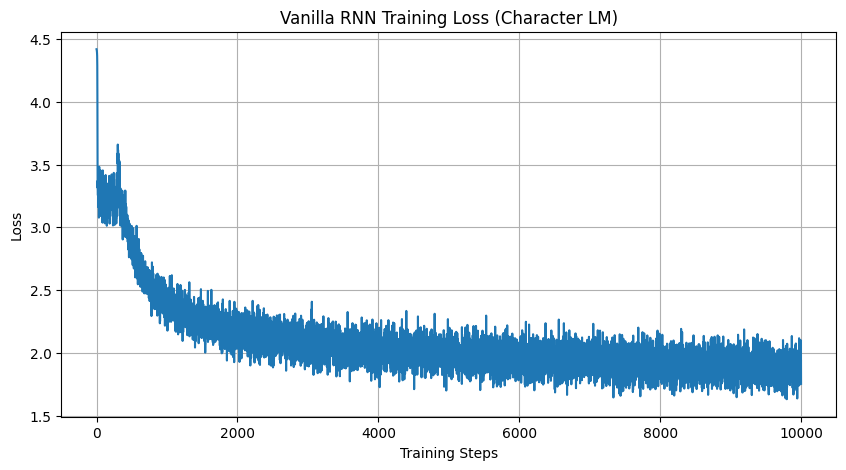

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Vanilla RNN Training Loss (Character LM)")
plt.grid(True)
plt.show()


In [95]:
def generate_text(cell, start_str, length=300, temperature=1.0):
    cell.eval()

    idxs = torch.tensor([char_to_idx[c] for c in start_str]).unsqueeze(0)
    h = torch.zeros(1, cell.hidden_size)

    # Warm-up pass (NO generation yet)
    for t in range(idxs.size(1) - 1):
        h, _ = cell(idxs[:, t], h)

    idx = idxs[:, -1]
    generated = list(start_str)

    for _ in range(length):
        h, logits = cell(idx, h)
        logits = logits / temperature

        probs = F.softmax(logits.squeeze(0), dim=-1)
        idx = torch.multinomial(probs, 1)

        generated.append(idx_to_char[idx.item()])

    return "".join(generated)


In [97]:
print(generate_text(cell, "The ", 400, temperature=0.2))

The such the so me the so make the do thy so stare the with the mand the so her the prainst the dear the part the world all the preath the king his prain the prainst the compore the dear the preath the commen the so make the so the prove the prown in the so not the make the such and to the so make the so not the such and the come that the mand the preat the say the so love as and the so the so make to


🔹 Temperature = 0.2
Interpretation:
✔ Model is confident
❌ Diversity collapsed

In [98]:
print(generate_text(cell, "The ", 400, temperature=0.7))

The is shom hath and cen reters the we munged is you swelt me trungrace.

CLOWN.
Or Parown,
I so me all en live I’s by to of the he dist and fleare your mo shoue till me eamact that be recess make of lead by they secauct for the will a detang; and hath whor the Sthen thould sin,
In was a may thy sence tane to fidith and worth and come the say.

HELENA.
With thou canse munter france sommente eare me th


Temperature = 0.7 (sweet spot)
Interpretation:
✔ Model learned local word structure
❌ Long-range grammar still weak

| Capability           | Status       |
| -------------------- | ------------ |
| Character statistics | ✅ Learned    |
| Word shapes          | ✅ Learned    |
| Local grammar        | ⚠️ Partial   |
| Sentence meaning     | ❌ Fails      |
| Long-range memory    | ❌ Impossible |


In [99]:
print(generate_text(cell, "The ", 400, temperature=1.0))

The ex than
Thy po; enture
Where avy me trt you woursele?
Of that he go lorsty
I fake ap proven my lomyerendlespofle for thand oor detorape, and I dening hase,
  I carnie, and Pany like a lortases truly tod him;—fored sporty, be det fice
But nide. I that he rithat tombered seafe namiiildeidgiom In vary ha thiness madam.
For as some donend,
The brick, on gond;
So what it lond,
That of th
  I Gordeive m


🔹 Temperature = 1.0
Interpretation:
✔ Model has partial grammar
✔ Some spelling errors expected

In [100]:
print(generate_text(cell, "The ", 400, temperature=1.2))

The offech did quick the notAnfoo hath redand yensty hought didlaze mor
Denem, with speareloy lose.
My,
RinRoule gov, I quountendsiled nom! ‘If Timeanies when not prall.
’ inespect
Ars I have pr paruil
toom hath my dight-heaved.
_mon f I n yes    lievern.
You nouchan,
Whatu hy indeces and:
You is wertuson is g so, this repth to yourb the stilut to ldeee could all upbe do sce weands.
Thrsinted me to co


Temperature = 1.2
Interpretation:
✔ Reveals brittleness
✔ Model not robust to randomness

In [53]:
# model is learning chracter statistics not language structure that's why results are bad 